<a href="https://colab.research.google.com/github/Purva1204/DL_LAB_assignments/blob/main/Assignment-3/Assignment_3_Forward_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)

Dataset shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [ ]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Normalization completed.")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Normalization completed.
Training data shape: (120, 4)
Testing data shape: (30, 4)


In [ ]:
def create_model(learning_rate):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(4,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Create model
model = create_model(0.01)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    verbose=0
)

print("Training completed.")
print(
    "Final training accuracy:",
    round(history.history['accuracy'][-1] * 100, 2),
    "%"
)

Training completed.
Final training accuracy: 99.07 %


In [ ]:
learning_rates = [0.001, 0.01, 0.1]

results = {}

for lr in learning_rates:

    print("\nTraining with learning rate:", lr)

    model = create_model(lr)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=8,
        validation_split=0.1,
        verbose=0
    )

    results[lr] = history

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    print("Test Accuracy:", round(accuracy * 100, 2), "%")


Training with learning rate: 0.001
Test Accuracy: 93.33 %

Training with learning rate: 0.01
Test Accuracy: 96.67 %

Training with learning rate: 0.1
Test Accuracy: 96.67 %


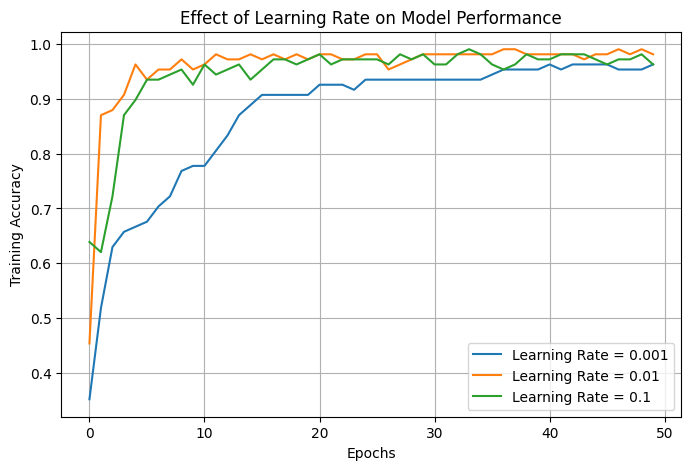

In [ ]:
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    plt.plot(
        results[lr].history['accuracy'],
        label="Learning Rate = " + str(lr)
    )

plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.title("Effect of Learning Rate on Model Performance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
epoch_values = [10, 30, 50, 100]

epoch_accuracies = []

for epochs in epoch_values:

    print("\nTraining with", epochs, "epochs")

    model = create_model(0.01)

    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=8,
        validation_split=0.1,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    epoch_accuracies.append(accuracy)

    print(
        "Test Accuracy:",
        round(accuracy * 100, 2),
        "%"
    )


Training with 10 epochs
Test Accuracy: 93.33 %

Training with 30 epochs
Test Accuracy: 96.67 %

Training with 50 epochs
Test Accuracy: 96.67 %

Training with 100 epochs
Test Accuracy: 96.67 %


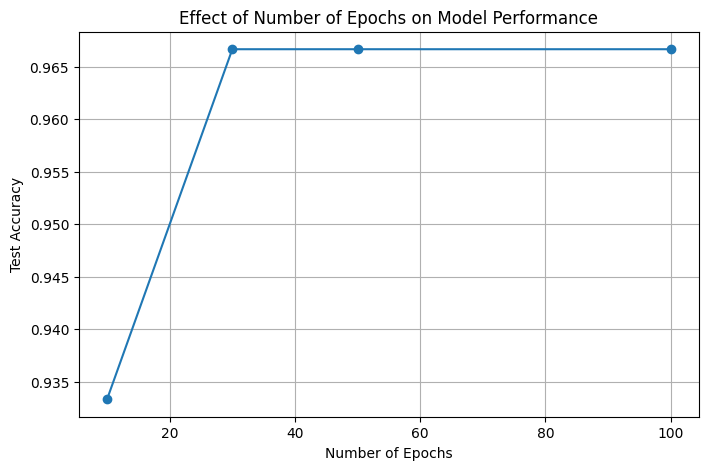

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epoch_values,
    epoch_accuracies,
    marker='o'
)

plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Epochs on Model Performance")
plt.grid(True)
plt.show()

In [ ]:
print("========== FINAL CONCLUSION ==========")

print("\nLearning Rate Results:")

for lr in learning_rates:
    final_accuracy = results[lr].history['accuracy'][-1]
    print(
        "Learning Rate:",
        lr,
        "-> Training Accuracy:",
        round(final_accuracy * 100, 2),
        "%"
    )

print("\nEpoch Results:")

for epochs, accuracy in zip(epoch_values, epoch_accuracies):
    print(
        "Epochs:",
        epochs,
        "-> Test Accuracy:",
        round(accuracy * 100, 2),
        "%"
    )

========== FINAL CONCLUSION ==========

Learning Rate Results:
Learning Rate: 0.001 -> Training Accuracy: 96.3 %
Learning Rate: 0.01 -> Training Accuracy: 98.15 %
Learning Rate: 0.1 -> Training Accuracy: 96.3 %

Epoch Results:
Epochs: 10 -> Test Accuracy: 93.33 %
Epochs: 30 -> Test Accuracy: 96.67 %
Epochs: 50 -> Test Accuracy: 96.67 %
Epochs: 100 -> Test Accuracy: 96.67 %
